# Likelihood: Foundations for Statistical Inference

## Overview

**Likelihood** is a fundamental concept in statistics and machine learning that answers the question: "Given the data we observed, how probable are different parameter values?"

Unlike probability (which assumes parameters are fixed and asks about data outcomes), likelihood treats data as fixed and examines which parameters best explain it.

### Why It Matters
1. **Maximum Likelihood Estimation (MLE)**: Finding parameters that maximize likelihood
2. **Model Comparison**: Comparing which model better explains the data
3. **Statistical Inference**: Foundation for Bayesian methods, hypothesis testing
4. **Machine Learning**: Core concept in supervised learning (gradient ascent maximizes likelihood)

### Key Distinction
- **Probability**: $P(\text{data} | \text{parameters})$ — Forward direction (fixed model, random data)
- **Likelihood**: $L(\text{parameters} | \text{data})$ — Backward direction (fixed data, variable parameters)

---

## Section 1: Probability vs Likelihood

### Side-by-Side Comparison

| Aspect | Probability | Likelihood |
|--------|-------------|------------|
| **Question Asked** | What data will I see? | What parameters explain my data? |
| **Fixed** | Model parameters $\theta$ | Observed data $D$ |
| **Variable** | Data/outcomes | Parameters $\theta$ |
| **Notation** | $P(D \| \theta)$ | $L(\theta \| D)$ |
| **Purpose** | Prediction | Inference/Estimation |
| **Inference Type** | Forward (generative) | Backward (discriminative) |
| **Scale** | Probability: $[0, 1]$ | Likelihood: Can be $> 1$ |

### Mathematical Relationship

Mathematically, they use the same formula:
$$L(\theta | D) = P(D | \theta)$$

**The key difference is interpretation**:
- In **probability**: We hold $\theta$ constant and vary $D$
- In **likelihood**: We hold $D$ constant and vary $\theta$

### Concrete Example: Coin Flips

**Experiment**: Flip a coin 3 times → Observed: **HHT** (2 heads, 1 tail)

**Probability Interpretation** (fixed p=0.5):
- "If the coin is fair (p=0.5), what's the probability of seeing HHT?"
- $P(HHT | p=0.5) = 0.5 \times 0.5 \times 0.5 = 0.125$

**Likelihood Interpretation** (fixed data HHT, varying p):
- "Given we observed HHT, which parameter p is most likely?"
- $L(p=0.5 | HHT) = 0.5 \times 0.5 \times 0.5 = 0.125$
- $L(p=0.6 | HHT) = 0.6 \times 0.6 \times 0.4 = 0.144$
- $L(p=0.7 | HHT) = 0.7 \times 0.7 \times 0.3 = 0.147$ ← **Maximum**

**Conclusion**: $p=0.67$ (2 heads out of 3) is the **most likely** parameter!

---

## Section 2: Mathematical Foundations

### 2.1 Likelihood Function

For independent samples, the likelihood is the product of individual probabilities:

**Form 1: Single Observation**
$$L_i(\theta) = P(x_i | \theta)$$

**Form 2: Multiple Independent Observations (n samples)**
$$L(\theta | D) = \prod_{i=1}^{n} P(x_i | \theta)$$

**Form 3: Log-Likelihood (numerical stability)**
$$\ell(\theta | D) = \log L(\theta | D) = \sum_{i=1}^{n} \log P(x_i | \theta)$$

We use log-likelihood because:
- Prevents numerical underflow (products become very small)
- Converts products to sums (computationally easier)
- Monotonic transformation: $\arg\max L = \arg\max \log L$

### 2.2 Likelihood for Common Distributions

#### Bernoulli Distribution (coin flips)
- Model: Binary outcome with probability $p$
- Single observation: $P(x | p) = p^x(1-p)^{1-x}$ where $x \in \{0, 1\}$
- Likelihood for $n$ observations: $L(p) = \prod_i p^{x_i}(1-p)^{1-x_i}$
- Log-likelihood: $\ell(p) = \sum_i [x_i \log p + (1-x_i)\log(1-p)]$

#### Gaussian (Normal) Distribution
- Model: Continuous data with mean $\mu$ and variance $\sigma^2$
- Single observation: $P(x | \mu, \sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$
- Log-likelihood: $\ell(\mu, \sigma) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_i(x_i - \mu)^2$

### 2.3 Maximum Likelihood Estimation (MLE)

**Goal**: Find the parameter value(s) that maximize the likelihood:
$$\theta^* = \arg\max_{\theta} L(\theta | D)$$

Or equivalently (using log-likelihood):
$$\theta^* = \arg\max_{\theta} \ell(\theta | D)$$

**Two approaches**:
1. **Analytical** (Closed-form): Take derivative and set to zero
   - $\frac{d\ell}{d\theta} = 0$ → solve for $\theta$
   - Works for simple models (Gaussian, Bernoulli)

2. **Numerical** (Iterative): Use gradient ascent
   - $\theta := \theta + \alpha \nabla \ell(\theta)$
   - Works for complex models (neural networks, logistic regression)

---

## Section 2B: Maximum Likelihood Estimation (Comprehensive)

### 2B.1 Core Principle

**Maximum Likelihood Estimation** is the process of finding parameter values that make the observed data **most probable** under the assumed model.

**Mathematical Definition**:
$$\hat{\theta}_{\text{MLE}} = \arg\max_{\theta} L(\theta | D) = \arg\max_{\theta} \prod_{i=1}^{n} P(x_i | \theta)$$

**Intuition**: Among all possible parameter settings, choose the one that would be most likely to generate the exact data we observed.

### 2B.2 MLE for Bernoulli Distribution (Detailed Example)

**Setup**: Flip a coin $n$ times, observe $k$ heads, $(n-k)$ tails

**Probability Function** (single observation):
$$P(x | p) = p^x(1-p)^{1-x} \quad \text{where } x \in \{0, 1\}$$

- $x = 1$ represents **heads** (success) → $P(x=1|p) = p$
- $x = 0$ represents **tails** (failure) → $P(x=0|p) = 1-p$

**Probability Function** (multiple observations):
$$P(D | p) = \prod_{i=1}^{n} p^{x_i}(1-p)^{1-x_i} = p^k(1-p)^{n-k}$$

where $k = \sum_{i=1}^{n} x_i$ (number of heads)

**Likelihood Function** (same mathematical form, different interpretation):
$$L(p | k \text{ heads, } n-k \text{ tails}) = p^k(1-p)^{n-k}$$

**Log-Likelihood**:
$$\ell(p) = k \log p + (n-k) \log(1-p)$$

**Finding MLE** (take derivative and set to zero):
$$\frac{d\ell}{dp} = \frac{k}{p} - \frac{n-k}{1-p} = 0$$

**Solve for $p$**:
$$\frac{k}{p} = \frac{n-k}{1-p}$$
$$k(1-p) = p(n-k)$$
$$k - kp = np - kp$$
$$k = np$$
$$\hat{p}_{\text{MLE}} = \frac{k}{n}$$

**Result**: The MLE for the success probability is simply the **empirical frequency**!

**Example**: If you flip a coin 10 times and get 7 heads:
$$\hat{p}_{\text{MLE}} = \frac{7}{10} = 0.7$$

### 2B.3 MLE for Gaussian Distribution (Detailed Example)

**Setup**: $n$ observations $x_1, \ldots, x_n$ assumed to come from $N(\mu, \sigma^2)$

**Likelihood Function**:
$$L(\mu, \sigma | D) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)$$

**Log-Likelihood**:
$$\ell(\mu, \sigma) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i - \mu)^2$$

**Finding MLE for $\mu$** (take derivative w.r.t. $\mu$):
$$\frac{\partial \ell}{\partial \mu} = \frac{1}{\sigma^2}\sum_{i=1}^{n}(x_i - \mu) = 0$$
$$\sum_{i=1}^{n}(x_i - \mu) = 0$$
$$\hat{\mu}_{\text{MLE}} = \frac{1}{n}\sum_{i=1}^{n}x_i$$

**Finding MLE for $\sigma^2$** (take derivative w.r.t. $\sigma^2$):
$$\frac{\partial \ell}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2}\sum_{i=1}^{n}(x_i - \mu)^2 = 0$$
$$\frac{n}{\sigma^2} = \frac{1}{\sigma^4}\sum_{i=1}^{n}(x_i - \mu)^2$$
$$\hat{\sigma}^2_{\text{MLE}} = \frac{1}{n}\sum_{i=1}^{n}(x_i - \hat{\mu})^2$$

**Result**: MLEs are the **sample mean** and **sample variance**!

**Example**: Data: [1, 2, 3, 4, 5]
- $\hat{\mu}_{\text{MLE}} = \frac{1+2+3+4+5}{5} = 3$
- $\hat{\sigma}^2_{\text{MLE}} = \frac{(1-3)^2 + (2-3)^2 + (3-3)^2 + (4-3)^2 + (5-3)^2}{5} = \frac{10}{5} = 2$

### 2B.4 MLE for Logistic Regression

**Setup**: Binary classification with $n$ examples $(x_i, y_i)$ where $y_i \in \{0, 1\}$

**Model**: $P(y=1|x; \theta) = \sigma(\theta^T x)$ where $\sigma$ is the sigmoid function

**Likelihood** (for single example):
$$L(\theta | x_i, y_i) = P(y_i | x_i; \theta)^{y_i} \cdot [1 - P(y_i | x_i; \theta)]^{1-y_i}$$

**Likelihood for all data**:
$$L(\theta | D) = \prod_{i=1}^{n} \sigma(\theta^T x_i)^{y_i} \cdot [1 - \sigma(\theta^T x_i)]^{1-y_i}$$

**Log-Likelihood** (Binary Cross-Entropy):
$$\ell(\theta | D) = \sum_{i=1}^{n} [y_i \log \sigma(\theta^T x_i) + (1-y_i) \log(1 - \sigma(\theta^T x_i))]$$

**Finding MLE**: No closed-form solution! Must use **gradient ascent**:
$$\theta^{(t+1)} := \theta^{(t)} + \alpha \nabla_\theta \ell(\theta^{(t)} | D)$$

Where:
$$\nabla_\theta \ell(\theta) = \sum_{i=1}^{n} [\sigma(\theta^T x_i) - y_i] x_i$$

### 2B.5 Comparison of MLE Solutions

| Model | Likelihood Form | MLE Solution | Type |
|-------|-----------------|--------------|------|
| **Bernoulli** | $p^k(1-p)^{n-k}$ | $\hat{p} = k/n$ | Closed-form |
| **Gaussian (μ)** | $\prod \exp(-(x_i-\mu)^2)$ | $\hat{\mu} = \bar{x}$ | Closed-form |
| **Gaussian (σ²)** | Variance form | $\hat{\sigma}^2 = \text{Var}(x)$ | Closed-form |
| **Logistic Regression** | Sigmoid likelihood | Via gradient ascent | Iterative |
| **Neural Network** | Complex composition | Via backprop + gradient ascent | Iterative |

### 2B.6 Properties of MLE

#### Property 1: Consistency
As sample size $n \to \infty$, $\hat{\theta}_{\text{MLE}} \to \theta^*$ (true parameter)

#### Property 2: Asymptotic Normality
For large $n$:
$$\hat{\theta}_{\text{MLE}} \sim N\left(\theta^*, \frac{1}{nI(\theta^*)}\right)$$
where $I(\theta)$ is the **Fisher Information Matrix**

#### Property 3: Efficiency
MLE achieves the **Cramér-Rao lower bound** (most efficient unbiased estimator)

#### Property 4: Invariance
If $\hat{\theta}$ is MLE of $\theta$, then $g(\hat{\theta})$ is MLE of $g(\theta)$

**Example**: If $\hat{\sigma}^2$ is MLE of variance, then $\sqrt{\hat{\sigma}^2}$ is MLE of std. dev

#### Property 5: Numerical Stability via Log-Likelihood
Always optimize $\ell(\theta)$ instead of $L(\theta)$ to avoid underflow

### 2B.7 Practical Algorithm for MLE

**Given**: Data $D = \{x_1, \ldots, x_n\}$, parametric model $p(x|\theta)$

**Algorithm**:
```
1. Write down likelihood: L(θ | D) = ∏ᵢ p(xᵢ | θ)
2. Take log-likelihood: ℓ(θ) = Σᵢ log p(xᵢ | θ)
3. Check if closed-form exists:
   a) If YES: Set ∇ℓ(θ) = 0 and solve for θ
   b) If NO: Use gradient ascent
      θ ← θ + α ∇ℓ(θ) until convergence
4. Return θ̂_MLE = argmax ℓ(θ)
```

### 2B.8 When to Use Closed-Form vs Gradient Ascent

| Scenario | Method | Why |
|----------|--------|-----|
| Simple, conjugate models | Closed-form | Fast, exact, interpretable |
| Complex, non-conjugate models | Gradient ascent | Flexible, scalable to high dimensions |
| Unknown derivatives | Finite differences | Numerical approximation, slower |
| Auto-differentiation available | Automatic differentiation | Accurate, efficient, scalable |

**Key Insight**: Most modern ML uses gradient ascent because data is high-dimensional and models are complex.

---

## Section 3: Likelihood Properties

### Property 1: Likelihood is Not a Probability

Likelihood can exceed 1!

**Example**: Uniform distribution on [0, 1]
- $P(x | \theta) = 1$ if $x \in [0, 1]$ and $\theta = 1$ (the parameter defining the range)
- For 10 samples: $L(\theta = 1) = 1^{10} = 1$ ✓ (valid)
- For 100 samples: We might get $L(\theta) > 1$ with different parameters

**Why?** Likelihood is a density (in continuous case), not a probability. A density can be > 1.

### Property 2: Only Relative Likelihood Matters

We care about **which parameter is most likely**, not the absolute value:

$$\theta^* = \arg\max L(\theta) = \arg\max c \cdot L(\theta)$$

where $c$ is any positive constant.

**Practical implication**: We can ignore constants in the likelihood function.

### Property 3: Log-Likelihood is Monotonic with Likelihood

Since $\log$ is monotonically increasing:
$$\arg\max L(\theta) = \arg\max \log L(\theta)$$

This is why we optimize log-likelihood instead of likelihood:
- Numerically more stable (avoids underflow with small probabilities)
- Computationally easier (products → sums)
- Same optimal parameters $\theta^*$

---

## Section 4: Key Takeaways

### Core Concepts

1. **Likelihood is backward inference**
   - Data is fixed; parameters vary
   - Question: "Which parameters best explain the data?"

2. **Likelihood and probability are mathematically identical**
   - Same formula: $L(\theta|D) = P(D|\theta)$
   - Different interpretation: likelihood varies parameters; probability varies outcomes

3. **Maximum Likelihood Estimation finds most likely parameters**
   - Analytical: Solve $\frac{d\ell}{d\theta} = 0$
   - Numerical: Use gradient ascent on log-likelihood

4. **Log-likelihood is preferred in practice**
   - Numerical stability (no underflow)
   - Computational efficiency (products → sums)
   - Optimal parameters unchanged: $\arg\max L = \arg\max \log L$

### Practical Applications

- **Logistic Regression**: Maximizes log-likelihood using gradient ascent
- **Neural Networks**: Loss functions often derived from negative log-likelihood
- **Model Selection**: Compare likelihoods across models (higher = better fit)
- **Probabilistic Models**: Variational Autoencoders, Gaussian Mixture Models use MLE

### Connection to Machine Learning

In supervised learning with gradient ascent:
- **Objective**: Maximize $J(\theta) = \ell(\theta | D)$ (log-likelihood)
- **Update**: $\theta := \theta + \alpha \nabla J(\theta)$ (move toward higher likelihood)
- **Result**: $\theta^*$ that best explains the observed data

---

## References

### Key Concepts
- **Maximum Likelihood Estimation**: Statistical principle of finding most probable parameters
- **Log-Likelihood**: Logarithm of likelihood function for numerical stability
- **Gradient Ascent**: Optimization method for finding MLE with large/complex datasets

### Related Topics
- Batch Gradient Ascent (ml_001_06)
- Probabilistic Linear Regression (ml_001_01)
- Logistic Regression (in ml_001_00)
- Bayesian Inference (uses likelihood via Bayes' theorem)

/tmp/ipykernel_81458/3471987294.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(mle_boxes, labels=ns)


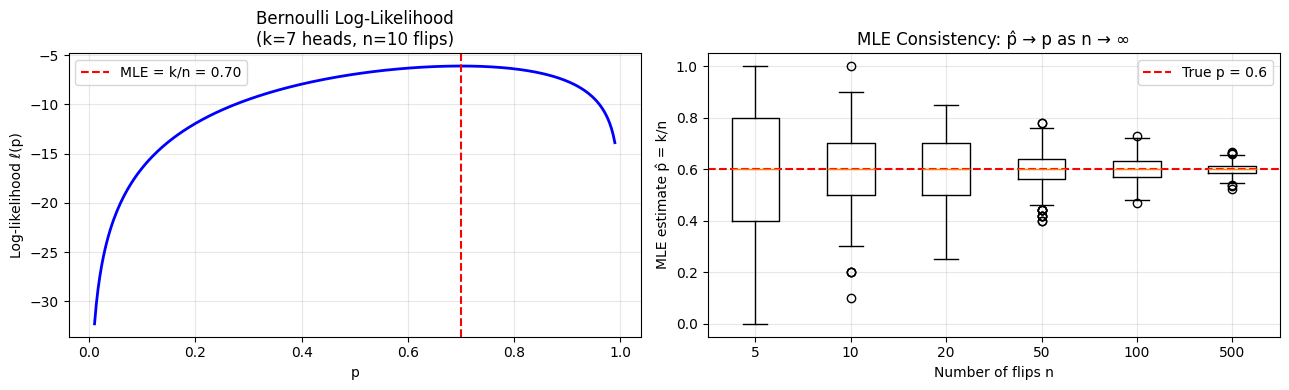

Analytical MLE:   p̂ = k/n = 7/10 = 0.7000
Numerical MLE:    p̂ = 0.7000
Log-likelihood at MLE: -6.1086


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

np.random.seed(42)

# --- Bernoulli MLE ---
# Observed: k=7 heads out of n=10 flips
k, n = 7, 10

p_vals = np.linspace(0.01, 0.99, 300)
# log-likelihood for Bernoulli: k*log(p) + (n-k)*log(1-p)
log_lik = k * np.log(p_vals) + (n - k) * np.log(1 - p_vals)

# analytical MLE is always k/n
p_mle = k / n

# numerical confirmation via scipy
result = minimize_scalar(
    lambda p: -(k * np.log(p) + (n - k) * np.log(1 - p)),
    bounds=(0.01, 0.99),
    method="bounded",
)
p_mle_num = result.x

# consistency: how MLE converges to true p as n grows
p_true = 0.6
ns = [5, 10, 20, 50, 100, 500]
mle_boxes = [np.random.binomial(n_val, p_true, size=500) / n_val for n_val in ns]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(p_vals, log_lik, "b-", lw=2)
axes[0].axvline(p_mle, color="r", linestyle="--", label=f"MLE = k/n = {p_mle:.2f}")
axes[0].set_xlabel("p")
axes[0].set_ylabel("Log-likelihood ℓ(p)")
axes[0].set_title(f"Bernoulli Log-Likelihood\n(k={k} heads, n={n} flips)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].boxplot(mle_boxes, labels=ns)
axes[1].axhline(p_true, color="r", linestyle="--", label=f"True p = {p_true}")
axes[1].set_xlabel("Number of flips n")
axes[1].set_ylabel("MLE estimate p̂ = k/n")
axes[1].set_title("MLE Consistency: p̂ → p as n → ∞")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Analytical MLE:   p̂ = k/n = {k}/{n} = {p_mle:.4f}")
print(f"Numerical MLE:    p̂ = {p_mle_num:.4f}")
print(f"Log-likelihood at MLE: {k * np.log(p_mle) + (n-k)*np.log(1-p_mle):.4f}")

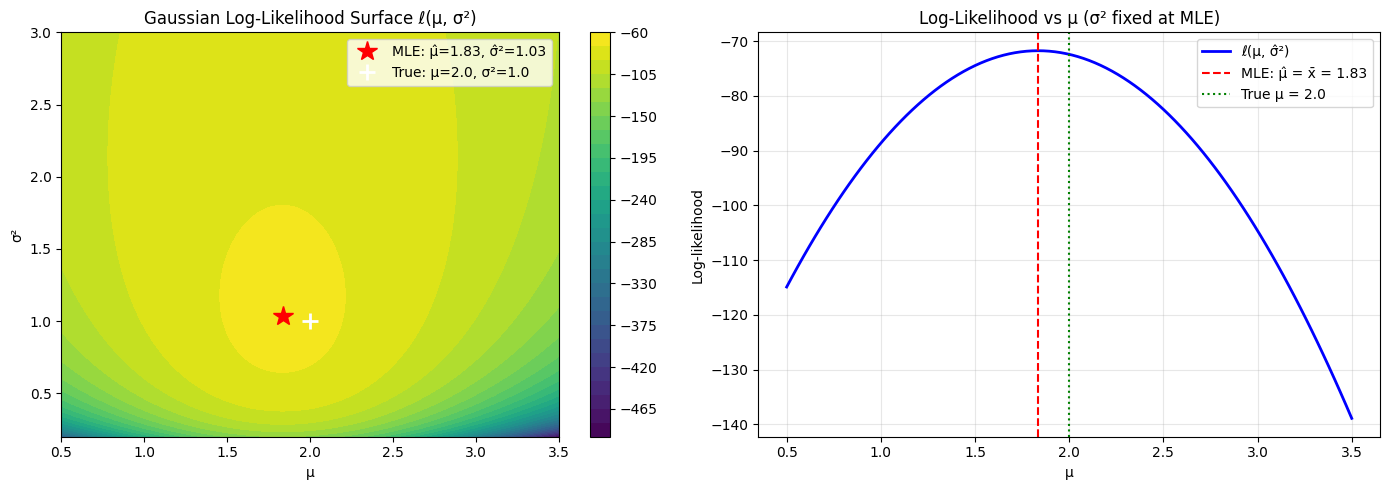

True:           μ = 2.0,  σ² = 1.0
MLE (biased):   μ̂ = 1.8349,  σ̂² = 1.0325  (divides by n=50)
Unbiased S²:        σ² = 1.0536  (divides by n-1=49)

Likelihood can exceed 1: f(0) for N(0,0.01) = 3.99 >> 1


In [5]:
# --- Gaussian MLE: log-likelihood surface ---
# True parameters: mu=2, sigma^2=1
mu_true, sigma2_true = 2.0, 1.0
n_samples = 50
data = np.random.normal(mu_true, np.sqrt(sigma2_true), n_samples)

# MLE estimates
mu_hat = np.mean(data)
# biased: divides by n
sigma2_mle = np.mean((data - mu_hat) ** 2)
# unbiased: divides by n-1
sigma2_unbiased = np.var(data, ddof=1)


def gaussian_ll(mu, sigma2, data):
    n = len(data)
    return -n / 2 * np.log(2 * np.pi * sigma2) - np.sum((data - mu) ** 2) / (2 * sigma2)


mu_grid = np.linspace(0.5, 3.5, 100)
sigma2_grid = np.linspace(0.2, 3.0, 100)
MU, S2 = np.meshgrid(mu_grid, sigma2_grid)
LL = np.array([[gaussian_ll(m, s2, data) for m in mu_grid] for s2 in sigma2_grid])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cs = axes[0].contourf(MU, S2, LL, levels=30, cmap="viridis")
plt.colorbar(cs, ax=axes[0])
axes[0].plot(mu_hat, sigma2_mle, "r*", markersize=15, label=f"MLE: μ̂={mu_hat:.2f}, σ̂²={sigma2_mle:.2f}")
axes[0].plot(mu_true, sigma2_true, "w+", markersize=12, markeredgewidth=2, label=f"True: μ={mu_true}, σ²={sigma2_true}")
axes[0].set_xlabel("μ")
axes[0].set_ylabel("σ²")
axes[0].set_title("Gaussian Log-Likelihood Surface ℓ(μ, σ²)")
axes[0].legend()

# slice: ll vs mu with sigma2 fixed at MLE value
ll_vs_mu = [gaussian_ll(m, sigma2_mle, data) for m in mu_grid]
axes[1].plot(mu_grid, ll_vs_mu, "b-", lw=2, label="ℓ(μ, σ̂²)")
axes[1].axvline(mu_hat, color="r", linestyle="--", label=f"MLE: μ̂ = x̄ = {mu_hat:.2f}")
axes[1].axvline(mu_true, color="g", linestyle=":", label=f"True μ = {mu_true}")
axes[1].set_xlabel("μ")
axes[1].set_ylabel("Log-likelihood")
axes[1].set_title("Log-Likelihood vs μ (σ² fixed at MLE)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"True:           μ = {mu_true},  σ² = {sigma2_true}")
print(f"MLE (biased):   μ̂ = {mu_hat:.4f},  σ̂² = {sigma2_mle:.4f}  (divides by n={n_samples})")
print(f"Unbiased S²:        σ² = {sigma2_unbiased:.4f}  (divides by n-1={n_samples-1})")
print(f"\nLikelihood can exceed 1: f(0) for N(0,0.01) = {1/np.sqrt(2*np.pi*0.01):.2f} >> 1")


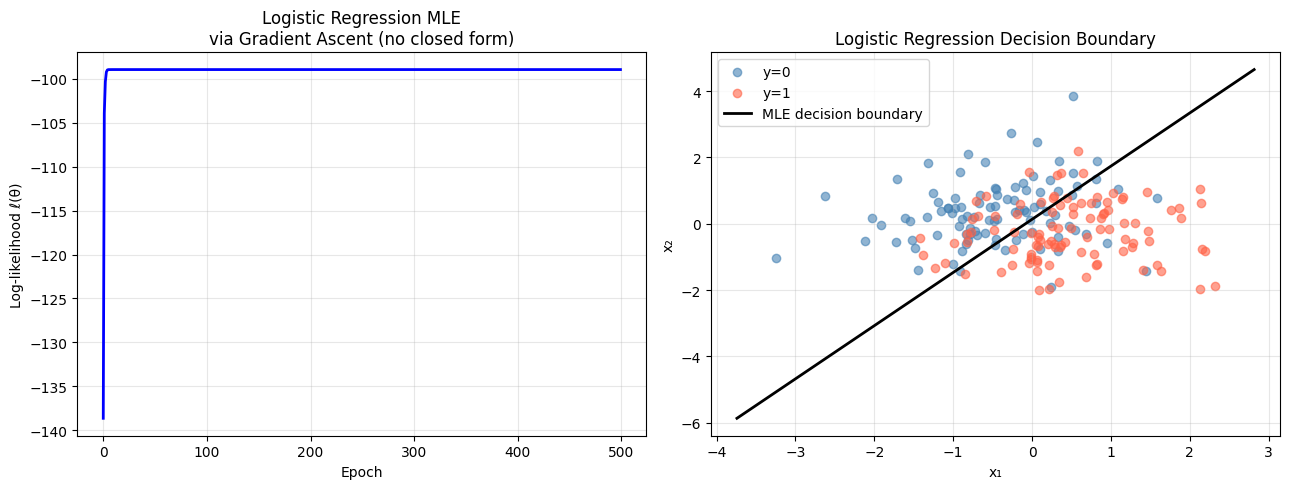

True θ:       [ 0.   1.5 -1. ]
MLE θ̂:        [ 0.1291  1.5415 -0.9616]
Final log-likelihood: -98.96
Accuracy: 76.0%

Key insight: sigmoid's composition with the linear term prevents a
closed-form solution — gradient ascent is the only option.


In [6]:
# --- Logistic Regression MLE via Gradient Ascent ---
# No closed form exists because sigmoid wraps the linear predictor
np.random.seed(42)


def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))


# Generate linearly separable binary data
n_cls, p_cls = 200, 2
X_cls = np.random.randn(n_cls, p_cls)
theta_true_cls = np.array([1.5, -1.0])
probs = sigmoid(X_cls @ theta_true_cls)
y_cls = (np.random.rand(n_cls) < probs).astype(float)

# augment with intercept
X_aug = np.hstack([np.ones((n_cls, 1)), X_cls])
theta_true_aug = np.concatenate([[0], theta_true_cls])


def log_likelihood_logistic(theta, X, y):
    z = X @ theta
    return np.sum(y * np.log(sigmoid(z) + 1e-15) + (1 - y) * np.log(1 - sigmoid(z) + 1e-15))


def grad_logistic(theta, X, y):
    # gradient of log-likelihood: X^T (y - sigma(X theta))
    return X.T @ (y - sigmoid(X @ theta))


# gradient ascent
theta = np.zeros(X_aug.shape[1])
alpha_lr = 0.05
ll_history = []

for _ in range(500):
    ll_history.append(log_likelihood_logistic(theta, X_aug, y_cls))
    theta += alpha_lr * grad_logistic(theta, X_aug, y_cls)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ll_history, "b-", lw=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Log-likelihood ℓ(θ)")
axes[0].set_title("Logistic Regression MLE\nvia Gradient Ascent (no closed form)")
axes[0].grid(alpha=0.3)

# decision boundary: theta[0] + theta[1]*x1 + theta[2]*x2 = 0
x1_range = np.linspace(X_cls[:, 0].min() - 0.5, X_cls[:, 0].max() + 0.5, 200)
x2_boundary = -(theta[0] + theta[1] * x1_range) / theta[2]

axes[1].scatter(X_cls[y_cls == 0, 0], X_cls[y_cls == 0, 1], alpha=0.6, label="y=0", c="steelblue")
axes[1].scatter(X_cls[y_cls == 1, 0], X_cls[y_cls == 1, 1], alpha=0.6, label="y=1", c="tomato")
axes[1].plot(x1_range, x2_boundary, "k-", lw=2, label="MLE decision boundary")
axes[1].set_xlabel("x₁")
axes[1].set_ylabel("x₂")
axes[1].set_title("Logistic Regression Decision Boundary")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

accuracy = np.mean((sigmoid(X_aug @ theta) > 0.5) == y_cls)
print(f"True θ:       {theta_true_aug}")
print(f"MLE θ̂:        {np.round(theta, 4)}")
print(f"Final log-likelihood: {ll_history[-1]:.2f}")
print(f"Accuracy: {accuracy:.1%}")
print("\nKey insight: sigmoid's composition with the linear term prevents a")
print("closed-form solution — gradient ascent is the only option.")

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Distinguish** probability from likelihood — same formula, fundamentally different interpretation
2. **Write** the likelihood function for Bernoulli, Gaussian, and logistic regression models
3. **Derive** MLE closed-form solutions for Bernoulli ($\hat{p} = k/n$) and Gaussian ($\hat{\mu} = \bar{x}$) analytically
4. **Explain** why log-likelihood is always preferred over raw likelihood in computation
5. **Describe** the four key properties of MLE: consistency, asymptotic normality, efficiency, and invariance
6. **Select** the correct optimization approach (closed-form vs. gradient ascent) for a given model

> **Prerequisite**: Calculus (derivatives, partial derivatives); probability basics (ml_000_01).
> **How to use**: The derivation sections contain step-by-step proofs — work through each algebraic step by hand before moving on. Code examples in this notebook illustrate the concepts numerically.

---
## Practice Exercises

**Conceptual**

1. You observe $k = 7$ heads in $n = 10$ coin flips. (a) Write the Bernoulli log-likelihood $\ell(p)$. (b) Derive $\hat{p}_{\text{MLE}}$ analytically by setting $d\ell/dp = 0$. (c) Show that the MLE is $k/n$ — the empirical frequency — regardless of $n$ and $k$.

2. For the Gaussian model $\mathcal{N}(\mu, \sigma^2)$ with known $\sigma^2$, derive $\hat{\mu}_{\text{MLE}}$ from the log-likelihood. Then, keeping $\hat{\mu} = \bar{x}$ fixed, derive $\hat{\sigma}^2_{\text{MLE}}$. Show that $\hat{\sigma}^2_{\text{MLE}} = \frac{1}{n}\sum(x_i - \bar{x})^2$ is biased and explain why the corrected estimator $S^2 = \frac{1}{n-1}\sum(x_i - \bar{x})^2$ is unbiased.

3. Likelihood can exceed 1 for continuous distributions (it is a density, not a probability). Give a concrete example: for $X \sim \mathcal{N}(0, 0.01)$, compute $f(0)$ and show it is much greater than 1. Why does this not violate any axioms of probability?

4. MLE has four asymptotic properties: consistency, asymptotic normality, efficiency, and invariance. For each property, state what it means and give a concrete example of how it is useful in practice.

5. For logistic regression, the log-likelihood $\ell(\theta) = \sum_i [y_i \log \sigma(\theta^Tx_i) + (1-y_i)\log(1-\sigma(\theta^Tx_i))]$ has no closed-form maximizer. Explain precisely what makes it different from the Gaussian case — what property of $\sigma(\theta^Tx)$ prevents a closed-form solution?

**Numerical**

6. Implement MLE for the Bernoulli model from scratch: (a) generate 200 samples from $\text{Bernoulli}(p=0.7)$, (b) compute the log-likelihood for $p \in [0.01, 0.99]$, (c) plot the log-likelihood curve, (d) find the MLE numerically and verify it equals $k/n$.

7. Visualize the Gaussian log-likelihood surface: generate 50 samples from $\mathcal{N}(2, 1)$. Plot a 2D contour of $\ell(\mu, \sigma^2)$ over a grid of $(\mu, \sigma^2)$ values. Mark the MLE at $(\bar{x}, \hat{\sigma}^2_{\text{MLE}})$ and verify it is the maximum.

8. Demonstrate the invariance property: fit a Bernoulli MLE to get $\hat{p}$. Now compute the log-odds $\hat{\eta} = \log(\hat{p}/(1-\hat{p}))$. Show this equals the MLE of the log-odds (obtained by re-parameterizing the likelihood in terms of $\eta$ directly).

**Reflection**

9. In machine learning, we almost always minimize the **negative log-likelihood** (cross-entropy) rather than maximizing the likelihood. For neural networks on image classification, the cross-entropy loss is $-\sum_i \log P(y_i | x_i; \theta)$. Explain why this is exactly MLE in disguise, and why the "loss minimization" and "likelihood maximization" framings are mathematically identical.